In [1]:
import pandas as pd
import numpy as np

CSV_FILE = "nsac_with_track.csv"

df = pd.read_csv(CSV_FILE,header=0, index_col=[0, 1, 2])
df.index.names = ["gate", "group", "neuron_idx"]

neuron_idx = pd.to_numeric(df.index.get_level_values("neuron_idx"), errors="coerce")
df = df[~neuron_idx.isna()].copy()

df.index = pd.MultiIndex.from_arrays([
    df.index.get_level_values("gate"),
    df.index.get_level_values("group"),
    neuron_idx[~neuron_idx.isna()].astype(int)
], names=["gate", "group", "neuron_idx"])

df = df.astype(np.float32)

neurons = {}
for (gate, group, neuron_idx), row in df.iterrows():
    neurons.setdefault(gate, {}).setdefault(group, {})[int(neuron_idx)] = (
        row.to_numpy(dtype=np.float32, copy=True))

# Sanity checks
print("Available gates:")
for gate in neurons:
    print(" ", gate)

print("\nGroups per gate:")
for gate, groups in neurons.items():
    print(f" {gate}: {list(groups.keys())}")

# Safe example usage
gate = "q_proj"
group = "sensory"

if gate not in neurons:
    raise KeyError(f"Gate '{gate}' not found")

if group not in neurons[gate]:
    raise KeyError(f"Group '{group}' not found in gate '{gate}'")

available_indices = sorted(neurons[gate][group].keys())

if len(available_indices) == 0:
    raise RuntimeError(f"No neurons found for {gate}/{group}")

print(f"\nAvailable neuron indices for {gate}/{group}:")
print(available_indices[:10])

neuron_idx = available_indices[0]
example_trace = neurons[gate][group][neuron_idx]

print(f"\nUsing neuron index {neuron_idx}")
print("Trace shape:", example_trace.shape)
print("Mean Output (V):", float(example_trace.mean()))

def get_neuron_trace(neurons, gate, group, neuron_idx):
    return neurons[gate][group][neuron_idx]

def list_neurons(neurons, gate, group):
    return sorted(neurons[gate][group].keys())

Available gates:
  q_proj
  k_proj
  v_proj
  ncp_out

Groups per gate:
 q_proj: ['sensory', 'inter', 'command']
 k_proj: ['sensory', 'inter', 'command']
 v_proj: ['sensory', 'inter', 'command']
 ncp_out: ['sensory', 'inter', 'command', 'motor']

Available neuron indices for q_proj/sensory:
[42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

Using neuron index 42
Trace shape: (850,)
Mean Output (V): 0.3092552721500397


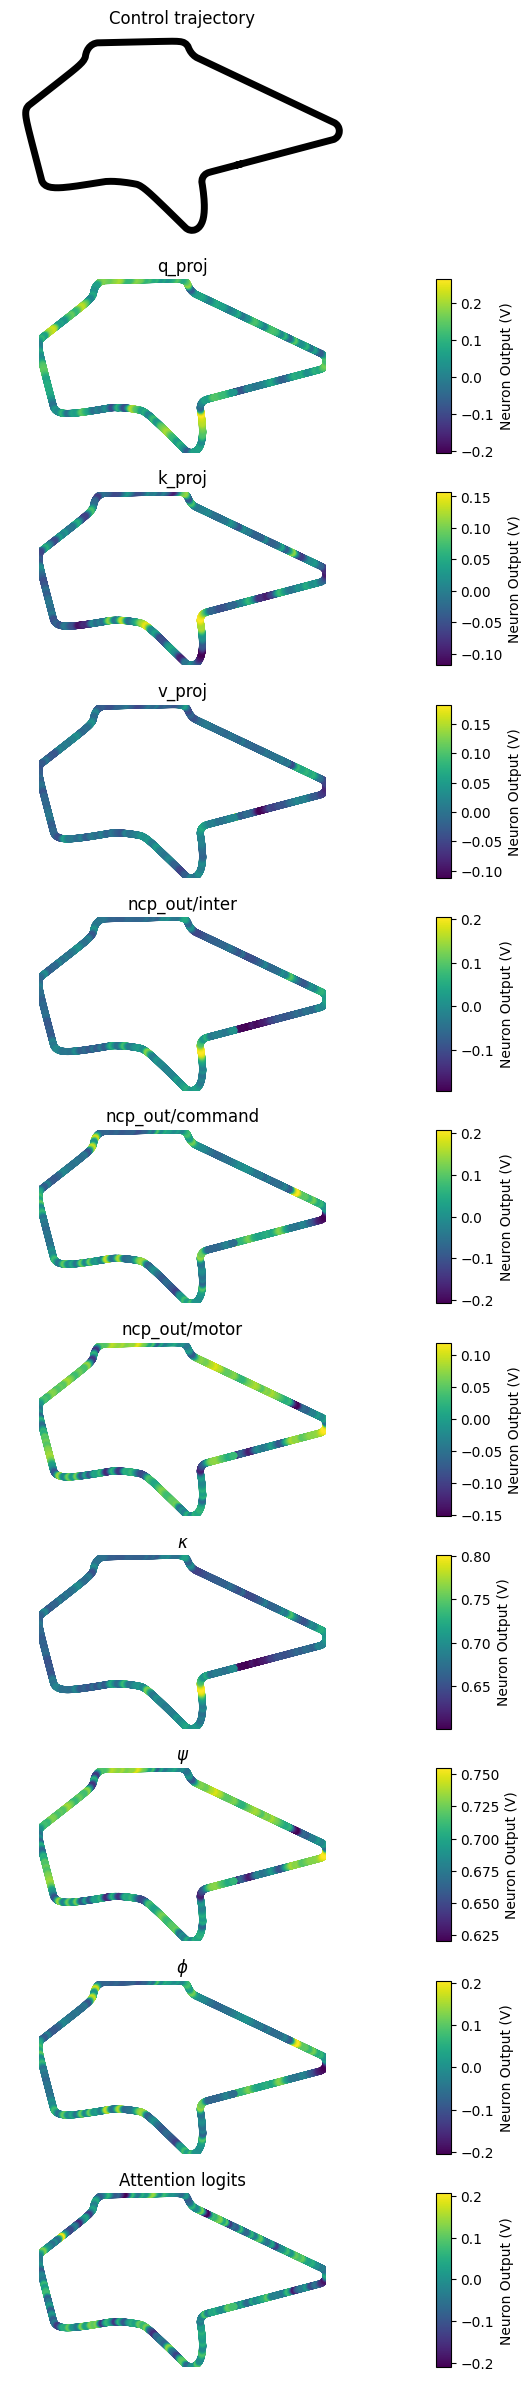

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

# CONFIG
CSV_FILE = "nsac_with_track.csv"

GATES_MAIN = ["q_proj", "k_proj", "v_proj"]
GROUP_MAIN = "sensory"

OUT_NCP_GATE = "ncp_out"
OUT_NCP_GROUPS = ["inter", "command", "motor"]

LINE_WIDTH = 5
UPSAMPLE = 10          
SMOOTH_SIGMA = 2.0   

# LOAD CSV
df = pd.read_csv(CSV_FILE, header=0, index_col=[0, 1, 2])
df.index.names = ["gate", "group", "neuron_idx"]
df = df.astype(np.float32)

num_points = df.shape[1]

# BUILD NEURON DICTIONARY
neurons = {}
for (gate, group, neuron_idx), row in df.iterrows():
    if not str(neuron_idx).isdigit():
        continue

    neurons.setdefault(gate, {}) \
           .setdefault(group, {})[int(neuron_idx)] = row.values.copy()

# MEAN TRACE PER GROUP (q/k/v)
traces_main = {}
for gate in GATES_MAIN:
    group_neurons = neurons.get(gate, {}).get(GROUP_MAIN, {})
    traces_matrix = np.array(list(group_neurons.values()))
    traces_main[gate] = traces_matrix.mean(axis=0)

# MEAN TRACE PER GROUP (out_ncp)
inter_neurons = list(neurons[OUT_NCP_GATE]["inter"].values())
inter_matrix = np.array(inter_neurons)

num_inter = inter_matrix.shape[0]
split_sizes = np.array_split(np.arange(num_inter), 3)

traces_out = {
    "inter": inter_matrix[split_sizes[0]].mean(axis=0),
    "command": inter_matrix[split_sizes[1]].mean(axis=0),
    "motor": inter_matrix[split_sizes[2]].mean(axis=0),
}

# MOTOR TRANSFORMS
kappa = traces_out["inter"]
phi = traces_out["command"]
psi = traces_out["motor"]

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softplus(x):
    return np.log1p(np.exp(x))

def softmax(x):
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

phi = np.tanh(phi)
kappa = softplus(kappa)
psi = softplus(psi)

# attention logits should be Orsenterin UhlenbheckU dynamics
dt = 0.5
mean = phi * (1.0 - np.exp(-kappa * dt))
var = (psi ** 2) * (1.0 - np.exp(-2.0 * kappa * dt)) / (2.0 * kappa)
ou_stddev = np.sqrt(np.maximum(var, 1e-9))
noise = ou_stddev * np.random.normal(scale=ou_stddev, size=ou_stddev.shape)
attention_logits = mean + noise
attention_weights = softmax(attention_logits)


# LOAD TRACK
center_x = df.loc[("track", "center", "x")].values
center_y = df.loc[("track", "center", "y")].values

mask = ~np.isnan(center_x) & ~np.isnan(center_y)
center_x = center_x[mask]
center_y = center_y[mask]

# PARAMETRIZE TRACK
dist = np.sqrt(np.diff(center_x)**2 + np.diff(center_y)**2)
s = np.insert(np.cumsum(dist), 0, 0)

if s[-1] == 0:
    s[-1] = 1e-6

s_norm = s / s[-1]

# safer interpolation (linear looks smoother visually)
fx = interp1d(s_norm, center_x, kind="linear")
fy = interp1d(s_norm, center_y, kind="linear")

t_base = np.linspace(0, 1.0, num_points)
x_curve = fx(t_base)
y_curve = fy(t_base)

# HEATMAP FUNCTION (FIXED)
def plot_heatmap(ax, x, y, values, title):
    # Smooth values slightly (optional but helps)
    values = gaussian_filter1d(values, sigma=SMOOTH_SIGMA)

    # UPSAMPLE EVERYTHING
    t_old = np.linspace(0, 1, len(values))
    t_new = np.linspace(0, 1, len(values) * UPSAMPLE)

    x = interp1d(t_old, x, kind="linear")(t_new)
    y = interp1d(t_old, y, kind="linear")(t_new)
    values = interp1d(t_old, values, kind="linear")(t_new)

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(vmin=values.min(), vmax=values.max())
    lc = LineCollection(segments, cmap="viridis", norm=norm)

    lc.set_array(values)
    lc.set_linewidth(LINE_WIDTH)
    lc.set_antialiased(True)
    lc.set_joinstyle('round')
    lc.set_capstyle('round')

    ax.add_collection(lc)
    ax.set_xlim(x.min() - 0.05, x.max() + 0.05)
    ax.set_ylim(y.min() - 0.05, y.max() + 0.05)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    return lc

# FIGURE
total_rows = 1 + len(GATES_MAIN) + len(OUT_NCP_GROUPS) + 5
fig = plt.figure(figsize=(6, 26))
gs = fig.add_gridspec(
    total_rows, 2,
    width_ratios=[1, 0.03],
    height_ratios=[1.2] + [1] * (total_rows - 1)
)

# CONTROL TRAJECTORY
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(x_curve, y_curve, color="black", linewidth=LINE_WIDTH)
ax0.set_aspect("equal")
ax0.axis("off")
ax0.set_title("Control trajectory")
fig.add_subplot(gs[0, 1]).axis("off")

# q / k / v
for i, gate in enumerate(GATES_MAIN):
    ax = fig.add_subplot(gs[i + 1, 0])
    cax = fig.add_subplot(gs[i + 1, 1])
    line = plot_heatmap(ax, x_curve, y_curve, traces_main[gate], gate)
    fig.colorbar(line, cax=cax).set_label("Neuron Output (V)")

# out_ncp
offset = 1 + len(GATES_MAIN)
for i, group in enumerate(OUT_NCP_GROUPS):
    ax = fig.add_subplot(gs[offset + i, 0])
    cax = fig.add_subplot(gs[offset + i, 1])
    line = plot_heatmap(
        ax,
        x_curve,
        y_curve,
        traces_out[group],
        f"{OUT_NCP_GATE}/{group}"
    )
    fig.colorbar(line, cax=cax).set_label("Neuron Output (V)")

# motor transforms
ax_phi = fig.add_subplot(gs[-5, 0])
cax_phi = fig.add_subplot(gs[-5, 1])
line_phi = plot_heatmap(ax_phi, x_curve, y_curve, kappa, r"$\kappa$")
fig.colorbar(line_phi, cax=cax_phi).set_label("Neuron Output (V)")

ax_omega = fig.add_subplot(gs[-4, 0])
cax_omega = fig.add_subplot(gs[-4, 1])
line_omega = plot_heatmap(ax_omega, x_curve, y_curve, psi, r"$\psi$")
fig.colorbar(line_omega, cax=cax_omega).set_label("Neuron Output (V)")

ax_logits = fig.add_subplot(gs[-3, 0])
cax_logits = fig.add_subplot(gs[-3, 1])
line_logits = plot_heatmap(ax_logits, x_curve, y_curve, phi, r"$\phi$")
fig.colorbar(line_logits, cax=cax_logits).set_label("Neuron Output (V)")

ax_weights = fig.add_subplot(gs[-2, 0])
cax_weights = fig.add_subplot(gs[-2, 1])
line_weights = plot_heatmap(ax_weights, x_curve, y_curve, attention_logits, "Attention logits")
fig.colorbar(line_weights, cax=cax_weights).set_label("Neuron Output (V)")


plt.tight_layout()
plt.show()

corrected

KeyError: 'command'

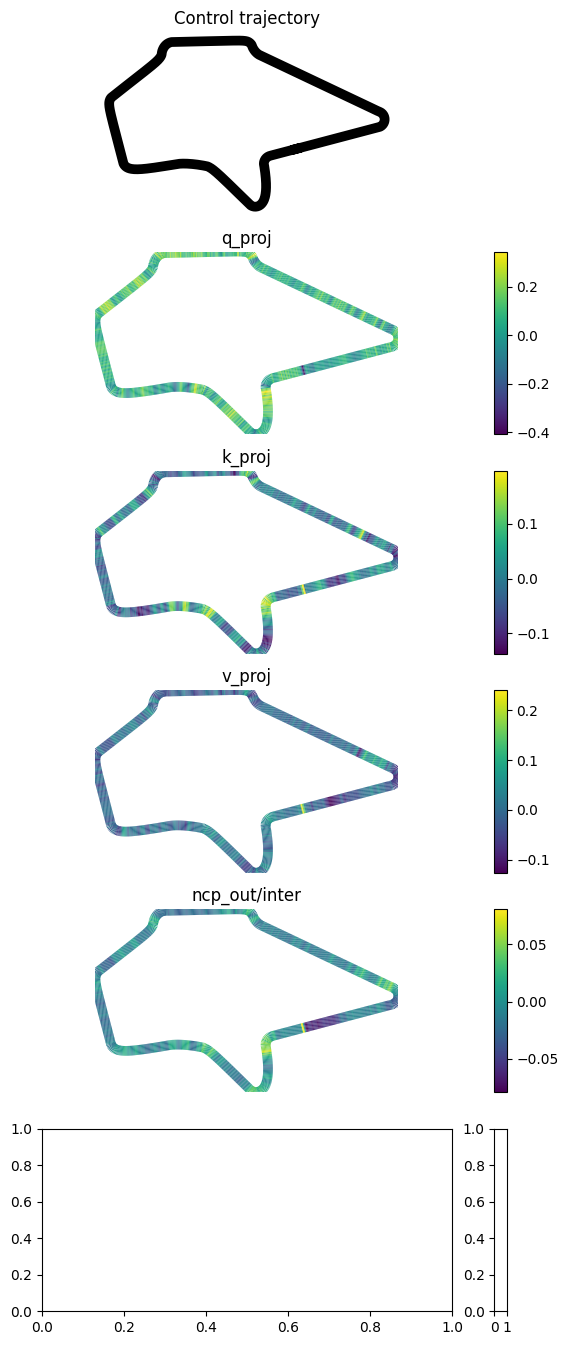

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from scipy.interpolate import interp1d

# CONFIG
CSV_FILE = "nsac_with_track.csv"

GATES_MAIN = ["q_proj", "k_proj", "v_proj"]
GROUP_MAIN = "sensory"

OUT_NCP_GATE = "ncp_out"
OUT_NCP_GROUPS = ["inter", "command", "motor"]

LINE_WIDTH = 7

# LOAD CSV
df = pd.read_csv(CSV_FILE, header=0, index_col=[0, 1, 2])
df.index.names = ["gate", "group", "neuron_idx"]
df = df.astype(np.float32)

num_points = df.shape[1]
t_vec = np.linspace(0, 1.0, num_points)

# ---------- HELPERS ----------
def filter_nonzero_rows(matrix):
    if matrix.size == 0:
        return matrix
    return matrix[~np.all(matrix == 0, axis=1)]

# ---------- BUILD NEURON DICTIONARY ----------
neurons = {}
for (gate, group, neuron_idx), row in df.iterrows():
    if not str(neuron_idx).isdigit():
        continue

    neurons.setdefault(gate, {}) \
           .setdefault(group, {})[int(neuron_idx)] = row.values.copy()

# ---------- Q / K / V MEANS ----------
traces_main = {}

for gate in GATES_MAIN:
    group_neurons = neurons.get(gate, {}).get(GROUP_MAIN, {})
    traces_matrix = np.array(list(group_neurons.values()))

    traces_matrix = filter_nonzero_rows(traces_matrix)

    if traces_matrix.size == 0:
        continue

    traces_main[gate] = traces_matrix.mean(axis=0)

# ---------- OUT NCP (FIXED) ----------
traces_out = {}

for group in OUT_NCP_GROUPS:
    group_neurons = neurons.get(OUT_NCP_GATE, {}).get(group, {})

    matrix = np.array(list(group_neurons.values()))
    matrix = filter_nonzero_rows(matrix)

    if matrix.size == 0:
        continue

    traces_out[group] = matrix.mean(axis=0)

# ---------- MOTOR TRANSFORM ----------
motor = traces_out["motor"]

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softplus(x):
    return np.log1p(np.exp(x))

def softmax(x):
    x = np.array(x)
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

phi_motor = sigmoid(motor)
omega_motor = softplus(motor)

attention_logits = phi_motor / (omega_motor + 1e-4)
attention_probs = softmax(attention_logits)

# ---------- ATTENDED VALUE ----------
v_proj = traces_main["v_proj"]
v_attended = attention_probs * v_proj

# ---------- LOAD TRACK ----------
center_x = df.loc[("track", "center", "x")].values
center_y = df.loc[("track", "center", "y")].values

mask = ~np.isnan(center_x) & ~np.isnan(center_y)
center_x = center_x[mask]
center_y = center_y[mask]

# ---------- PARAMETRIZE TRACK ----------
dist = np.sqrt(np.diff(center_x)**2 + np.diff(center_y)**2)
s = np.insert(np.cumsum(dist), 0, 0)

if s[-1] < 1e-8:
    s[-1] = 1e-8

s_norm = s / s[-1]

fx = interp1d(s_norm, center_x, kind="cubic", fill_value="extrapolate")
fy = interp1d(s_norm, center_y, kind="cubic", fill_value="extrapolate")

t_samples = np.linspace(0, 1.0, num_points)
x_curve = fx(t_samples)
y_curve = fy(t_samples)

# ---------- HEATMAP ----------
def plot_heatmap(ax, x, y, values, title):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(vmin=values.min(), vmax=values.max())
    lc = LineCollection(segments, cmap="viridis", norm=norm)

    lc.set_array(values[:-1])
    lc.set_linewidth(LINE_WIDTH)

    ax.add_collection(lc)
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.min(), y.max())
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    return lc

# ---------- FIGURE ----------
total_rows = 1 + len(GATES_MAIN) + len(OUT_NCP_GROUPS) + 3

fig = plt.figure(figsize=(6, 28))
gs = fig.add_gridspec(total_rows, 2, width_ratios=[1, 0.03])

# CONTROL TRAJECTORY
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(x_curve, y_curve, color="black", linewidth=LINE_WIDTH)
ax0.set_aspect("equal")
ax0.axis("off")
ax0.set_title("Control trajectory")
fig.add_subplot(gs[0, 1]).axis("off")

# Q / K / V
for i, gate in enumerate(GATES_MAIN):
    ax = fig.add_subplot(gs[i + 1, 0])
    cax = fig.add_subplot(gs[i + 1, 1])
    lc = plot_heatmap(ax, x_curve, y_curve, traces_main[gate], gate)
    fig.colorbar(lc, cax=cax)

# OUT NCP
offset = 1 + len(GATES_MAIN)
for i, group in enumerate(OUT_NCP_GROUPS):
    ax = fig.add_subplot(gs[offset + i, 0])
    cax = fig.add_subplot(gs[offset + i, 1])
    lc = plot_heatmap(
        ax,
        x_curve,
        y_curve,
        traces_out[group],
        f"{OUT_NCP_GATE}/{group}"
    )
    fig.colorbar(lc, cax=cax)

# LOGITS
ax1 = fig.add_subplot(gs[-3, 0])
cax1 = fig.add_subplot(gs[-3, 1])
lc1 = plot_heatmap(ax1, x_curve, y_curve, attention_logits, "Attention logits")
fig.colorbar(lc1, cax=cax1)

# SOFTMAX
ax2 = fig.add_subplot(gs[-2, 0])
cax2 = fig.add_subplot(gs[-2, 1])
lc2 = plot_heatmap(ax2, x_curve, y_curve, attention_probs, "Attention softmax")
fig.colorbar(lc2, cax=cax2)

# ATTENDED VALUE
ax3 = fig.add_subplot(gs[-1, 0])
cax3 = fig.add_subplot(gs[-1, 1])
lc3 = plot_heatmap(ax3, x_curve, y_curve, v_attended, "Attention × v_proj")
fig.colorbar(lc3, cax=cax3)

plt.tight_layout()
plt.show()

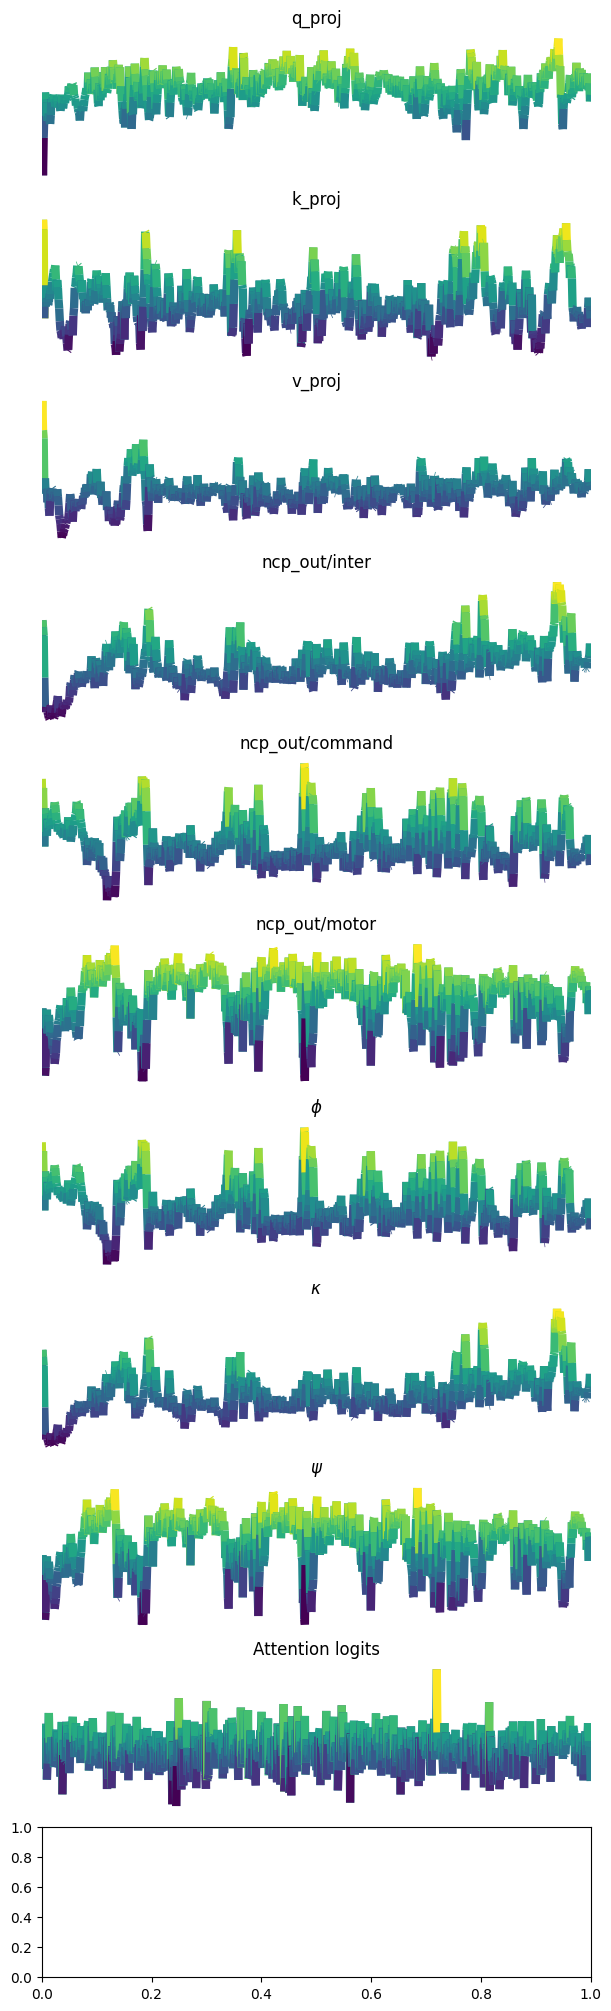

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

CSV_FILE = "nsac_with_track.csv"

GATES_MAIN = ["q_proj", "k_proj", "v_proj"]
GROUP_MAIN = "sensory"

OUT_NCP_GATE = "ncp_out"
OUT_NCP_GROUPS = ["inter", "command", "motor"]

LINE_WIDTH = 6

df = pd.read_csv(CSV_FILE, header=0, index_col=[0, 1, 2])
df.index.names = ["gate", "group", "neuron_idx"]
df = df.astype(np.float32)

num_points = df.shape[1]
t = np.arange(num_points)

neurons = {}
for (gate, group, neuron_idx), row in df.iterrows():
    neurons.setdefault(gate, {}) \
        .setdefault(group, {})[neuron_idx] = row.values.copy()


traces_main = {}
for gate in GATES_MAIN:
    group_neurons = neurons[gate][GROUP_MAIN]
    traces_matrix = np.array(list(group_neurons.values()))
    traces_main[gate] = traces_matrix.mean(axis=0)

inter_neurons = list(neurons[OUT_NCP_GATE]["inter"].values())
inter_matrix = np.array(inter_neurons)

num_inter = inter_matrix.shape[0]
split_sizes = np.array_split(np.arange(num_inter), 3)

traces_out = {
    "inter": inter_matrix[split_sizes[0]].mean(axis=0),
    "command": inter_matrix[split_sizes[1]].mean(axis=0),
    "motor": inter_matrix[split_sizes[2]].mean(axis=0),
}

# MOTOR TRANSFORMS
kappa = traces_out["inter"]
phi = traces_out["command"]
psi = traces_out["motor"]

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softplus(x):
    return np.log1p(np.exp(x))

def softmax(x):
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

phi = np.tanh(phi)
kappa = softplus(kappa)
psi = softplus(psi)

# attention logits should be Orsenterin UhlenbheckU dynamics
dt = 0.5
mean = phi * (1.0 - np.exp(-kappa * dt))
var = (psi ** 2) * (1.0 - np.exp(-2.0 * kappa * dt)) / (2.0 * kappa)
ou_stddev = np.sqrt(np.maximum(var, 1e-9))
noise = ou_stddev * np.random.normal(scale=ou_stddev, size=ou_stddev.shape)
attention_logits = mean + noise
attention_weights = softmax(attention_logits)

# =============================
def plot_heat_line(ax, x, y, title):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(vmin=y.min(), vmax=y.max())
    lc = LineCollection(segments, cmap="viridis", norm=norm)
    lc.set_array(y)
    lc.set_linewidth(LINE_WIDTH)

    ax.add_collection(lc)
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.min() - 0.05 * np.ptp(y), y.max() + 0.05 * np.ptp(y))
    ax.axis("off")
    ax.set_title(title)

    return lc

total_rows = len(GATES_MAIN) + len(OUT_NCP_GROUPS) + 5

fig, axes = plt.subplots(
    total_rows,
    1,
    figsize=(6, 20),
    constrained_layout=True
)

row = 0

# q / k / v
for gate in GATES_MAIN:
    plot_heat_line(axes[row], t, traces_main[gate], gate)
    row += 1

# out_ncp
for group in OUT_NCP_GROUPS:
    plot_heat_line(
        axes[row],
        t,
        traces_out[group],
        f"{OUT_NCP_GATE}/{group}"
    )
    row += 1

# motor transforms
plot_heat_line(axes[row], t, phi, r"$\phi$")
row += 1

plot_heat_line(axes[row], t, kappa, r"$\kappa$")
row += 1

plot_heat_line(axes[row], t, psi, r"$\psi$")
row += 1

plot_heat_line(axes[row], t, attention_logits, "Attention logits")
row += 1



plt.show()
